# 01 · The problem, the data, and the configuration

**The question this project asks:** given a photograph from an accommodation
listing, can a system work out which questions a traveller would actually want
answered before booking?

The pipeline has two stages. A zero-shot object detector finds amenities in the
photo: a bathtub, a kettle, a TV. A language model then turns each detection
into a question a guest might ask. The interesting part is not either stage
alone; it is what has to be true for the handoff between them to work.

This notebook covers the setup: what is configured, what the data looks like, and
what ships in this repository.

---

### A note on scope

This repository is a **portfolio walkthrough**, not the production system. The
full-scale experiments ran on the industry collaborator's internal
infrastructure; that code, its credentials, and its configuration are not
published here. What you see is the method, reimplemented against public APIs and
run over a small committed sample, alongside the **real results** from the
original runs.

Everything numeric in these notebooks comes from the committed CSVs. They are the actual
measurements, not re-simulated ones.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 90)

SAMPLE = REPO_ROOT / "data" / "sample"
RESULTS = REPO_ROOT / "results"
print("Repository root:", REPO_ROOT.name)


Repository root: portfolio-clean


## One code path, five amenities

The single biggest engineering decision in this project: every amenity runs
through the *same* code. The only things that differ are the text prompts and
the confidence sweep, and those live in `configs/amenities.yaml`.

The earlier version of this project had one ~1,200-line script per amenity, and
they were 86–99% identical to each other. Adding a sixth amenity now means adding
a YAML block.

In [2]:
from src.config import load_config

configs = load_config()

pd.DataFrame([
    {
        "amenity": key,
        "prompt sets": ", ".join(cfg.prompt_sets),
        "widest set": max(len(p) for p in cfg.prompt_sets.values()),
        "confidence sweep": f"{min(cfg.conf_sweep)} – {max(cfg.conf_sweep)}",
        "IoU threshold": cfg.eval_iou_threshold,
    }
    for key, cfg in configs.items()
])

,amenity,prompt sets,widest set,confidence sweep,IoU threshold
0,bathtub,"baseline, long, variants",9,0.05 – 0.45,0.5
1,hairdryer,"baseline, long, variants",6,0.05 – 0.45,0.5
2,kettle,"baseline, electric, rich_phrase, variants",6,0.05 – 0.45,0.5
3,mirror,"baseline, long, hybrid, variants",6,0.05 – 0.45,0.5
4,tv,"baseline, long, variants",6,0.05 – 0.45,0.5


## Prompt design

The detection-side research question is whether a richer text prompt helps an
open-vocabulary detector. Three families were tested:

| Family | Idea |
|:---|:---|
| `baseline` | the bare class name, `"kettle"` |
| `long` | one descriptive sentence |
| `variants` | several short synonyms and sub-types at once |

Intuition says `long` should win: more description, more signal for the text
encoder. Notebook 02 shows that intuition is wrong.

In [3]:
for key in ["kettle", "bathtub"]:
    cfg = configs[key]
    print(f"=== {cfg.display_name} ===")
    for name, prompts in cfg.prompt_sets.items():
        print(f"  {name:10s} {prompts}")
    print()

=== Kettle ===
  baseline   ['kettle']
  electric   ['electric kettle']
  rich_phrase ['tea kettle', 'water kettle', 'electric kettle']
  variants   ['kettle', 'electric kettle', 'stainless steel kettle', 'glass kettle', 'cordless kettle', 'hotel room kettle']

=== Bathtub ===
  baseline   ['bathtub']
  long       ['white ceramic bathtub in hotel bathroom, rectangular or oval-shaped']
  variants   ['bathtub', 'white bathtub', 'ceramic bathtub', 'built-in bathtub', 'freestanding bathtub', 'hotel bathtub', 'bathtub with shower', 'shower-over-bathtub', 'jacuzzi bathtub']



## Where the data comes from

The images are **real accommodation listing photographs provided by trivago
N.V.**, reproduced with permission. Not a general-purpose object-detection
benchmark repurposed for a hotel task; the actual domain the system targets.
A small number of images in the TV set are public stock photography.

Building the dataset was most of the work. The inventory carries coarse room
tags (bathroom, bedroom, kitchen) but no object-level labels, so images
containing a bathtub could not simply be queried. Candidates were pulled by room
tag and then reviewed by hand, one at a time; ambiguous, duplicated and corrupted
images were discarded. All metadata except the image itself was then stripped, so
no textual signal could leak into a pipeline meant to work from pixels alone.
Bounding boxes were drawn manually in a private Roboflow workspace.

**No annotated data trains anything.** OWL-ViT runs zero-shot; the annotations
exist purely to evaluate it.

The full splits are ~1,500 images and are not committed. A deterministic
46-image sample is, with attribution in
[`data/sample/ATTRIBUTION.md`](../data/sample/ATTRIBUTION.md).

In [4]:
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

# Photographs re-encode as PNG in notebook output, which is what drives .ipynb
# file size. 72 dpi keeps the committed notebooks light enough to render quickly
# on GitHub while staying perfectly legible.
plt.rcParams["figure.dpi"] = 72


def load_sample_coco(amenity):
    """Ground-truth boxes for the committed sample, keyed by file name."""
    coco = json.loads((SAMPLE / amenity / "_annotations.coco.json").read_text())
    by_id = {i["id"]: i["file_name"] for i in coco["images"]}
    boxes = {}
    for ann in coco["annotations"]:
        x, y, w, h = ann["bbox"]
        boxes.setdefault(by_id[ann["image_id"]], []).append([x, y, x + w, y + h])
    return coco, boxes


def show_detections(amenity, file_names, detections, gt_boxes, conf, ncols=3):
    """Green = ground truth, orange = detection above `conf`."""
    nrows = (len(file_names) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.2 * nrows))
    axes = axes.ravel() if hasattr(axes, "ravel") else [axes]

    for ax, name in zip(axes, file_names):
        ax.imshow(Image.open(SAMPLE / amenity / name).convert("RGB"))
        for x1, y1, x2, y2 in gt_boxes.get(name, []):
            ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                                   fill=False, edgecolor="#2E9B57", linewidth=2.5))
        hits = detections[(detections["image"] == name) & (detections["score"] > conf)]
        for _, d in hits.iterrows():
            ax.add_patch(Rectangle((d.x1, d.y1), d.x2 - d.x1, d.y2 - d.y1,
                                   fill=False, edgecolor="#E07B39", linewidth=2.0,
                                   linestyle="--"))
            ax.text(d.x1, max(d.y1 - 6, 10), f"{d.score:.2f}", color="#E07B39",
                    fontsize=9, fontweight="bold")
        n_gt = len(gt_boxes.get(name, []))
        ax.set_title(f"{n_gt} ground truth · {len(hits)} detected", fontsize=9)
        ax.axis("off")

    for ax in axes[len(file_names):]:
        ax.axis("off")
    fig.suptitle("green = ground truth    orange dashed = OWL-ViT detection",
                 fontsize=10, y=1.005)
    plt.tight_layout()
    plt.show()

rows = []
for key in configs:
    coco, boxes = load_sample_coco(key)
    n_images = len(coco["images"])
    n_boxes = sum(len(v) for v in boxes.values())
    rows.append({
        "amenity": key,
        "sample images": n_images,
        "ground-truth boxes": n_boxes,
        "images with no box": n_images - len(boxes),
    })

pd.DataFrame(rows)

,amenity,sample images,ground-truth boxes,images with no box
0,bathtub,10,8,2
1,hairdryer,10,9,2
2,kettle,10,8,2
3,mirror,8,9,0
4,tv,8,8,0


Images carrying no ground-truth box are deliberate. They are the **negative
set**: rooms where the amenity is genuinely absent. Precision and recall on
positive images say nothing about how often a detector hallucinates a kettle in a
bathroom, so those images are scored separately in notebook 02.

## What the data actually looks like

Worth looking at before trusting any metric computed from it.

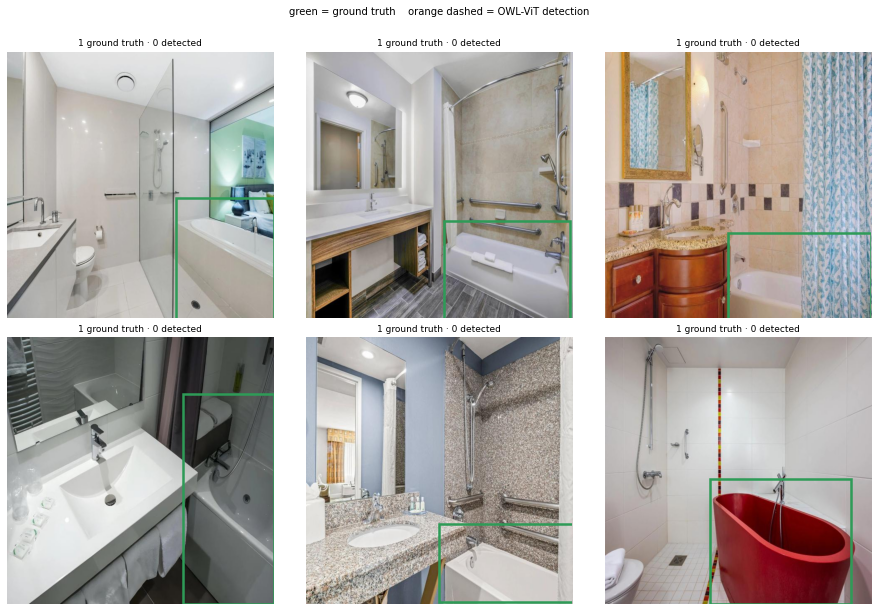

In [5]:
coco, gt = load_sample_coco("bathtub")
names = [i["file_name"] for i in coco["images"] if i["file_name"] in gt][:6]

empty = pd.DataFrame(columns=["image", "score", "x1", "y1", "x2", "y2"])
show_detections("bathtub", names, empty, gt, conf=1.0)

These are the honest limits of the dataset, and they bound everything that
follows:

- **Annotation tightness varies.** Some boxes hug the tub, others take in the
  surrounding tiling. That caps achievable IoU regardless of how good the
  detector is, and is part of why mean IoU sits well below F1.
- **The validation splits are small**, 18 images for bathtub and 52 for mirror.
  Too small for confident model selection, which is why threshold choices are
  reported as a sweep rather than a single tuned number.
- **A narrow slice of the domain.** Well-curated listings in three European
  cities, not a random sample of the inventory. Performance on lower-quality
  photography, or in other markets, is untested.

[`docs/dataset_inventory.md`](../docs/dataset_inventory.md) records the full
split sizes, provenance, and the integrity issues found during the audit.